<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="300" alt="cognitiveclass.ai logo">
</center>

# **Understanding  Generative Adversarial Networks GANs**

In this lab, we will focus on simulated data to better understand Generative Adversarial Networks (GANs).
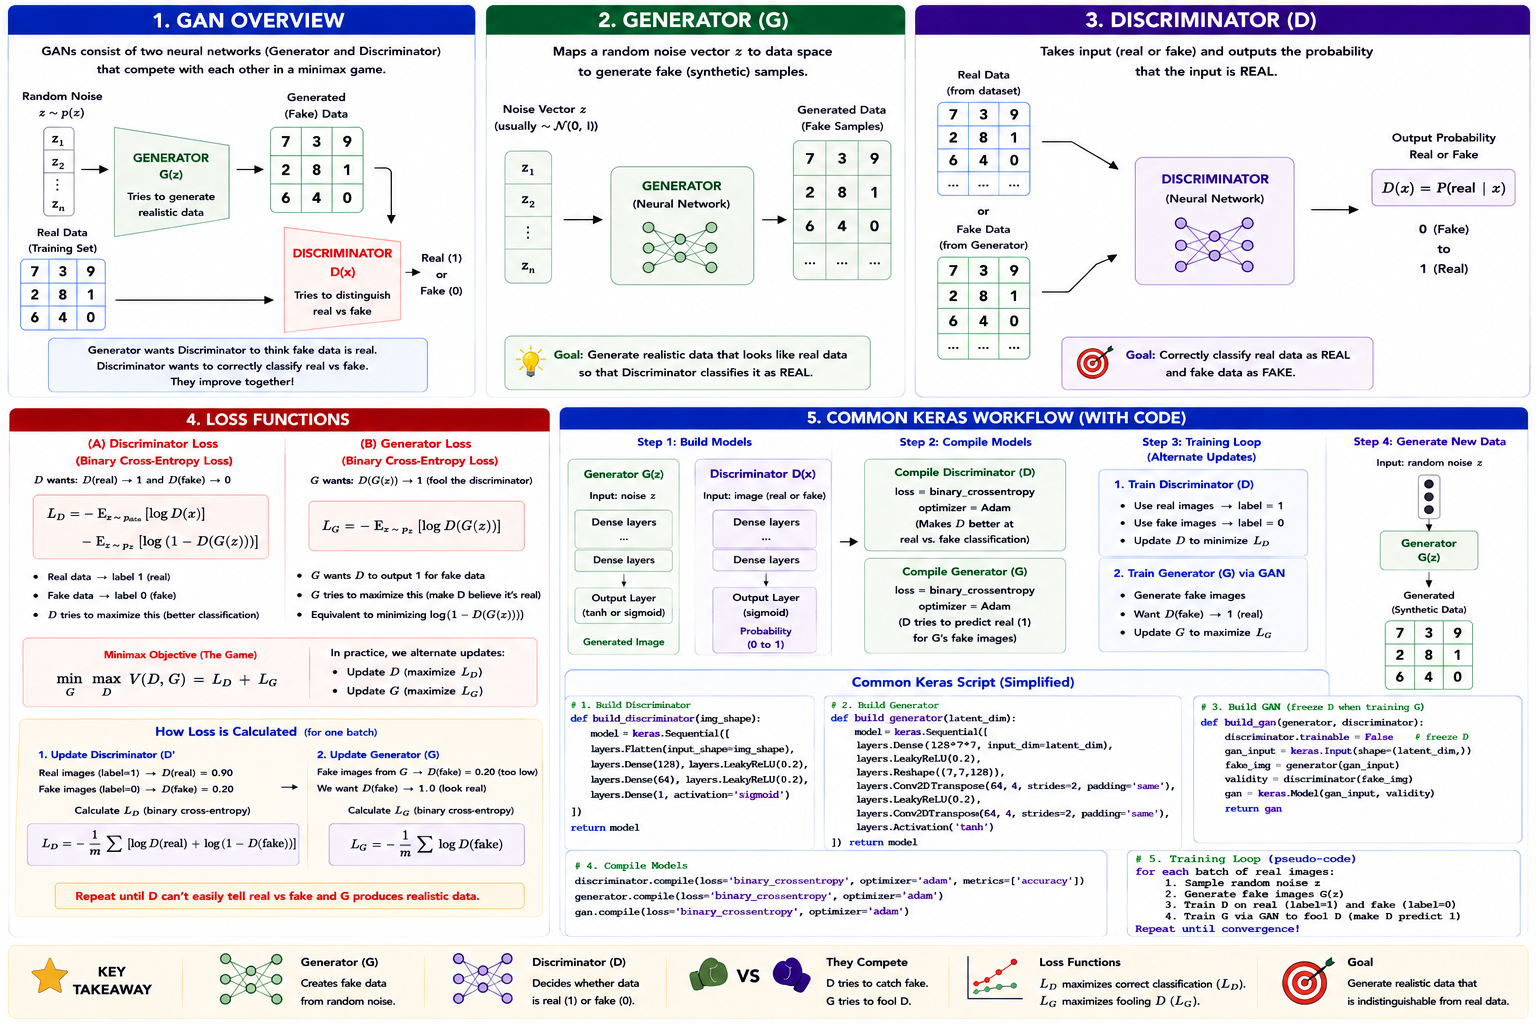

## **Table of Contents**

1. [Objectives](#Objectives)
2. [Setup](#Setup)
3. [Background](#Background)
4. [Toy Data](#Toy-Data)
5. [The Generator](#The-Generator)
6. [The Discriminator](#The-Discriminator)
7. [The Loss Function GANs (Optional)](#The-Loss-Function-GANs-Optional)
    1. [Discriminator](#Discriminator)
    2. [Generator](#Generator)
8. [Training GANs](#Training-GANs)
    1. [Training Generator](#Training-Generator)
    2. [Training Discriminator](#Training-Discriminator)
9. [Modified Version](#Modified-Version)    


<a id="Objectives"></a>
## **Objectives**

After completing this lab, you will be able to:

*   **Understand** the original formulation of GANs, and their two separately trained networks: Generator and Discriminator
*   **Implement** GANs on simulated and real datasets


<a id="Setup"></a>
For this lab, we will be using the following libraries:

*   [`pandas`](https://pandas.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for managing the data.
*   [`numpy`](https://numpy.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for mathematical operations.
*   [`sklearn`](https://scikit-learn.org/stable/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for machine learning and machine-learning-pipeline related functions.
*   [`seaborn`](https://seaborn.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for visualizing the data.
*   [`matplotlib`](https://matplotlib.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for additional plotting tools.
*   [`keras`](https://keras.io/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for loading datasets.


### **Installing Required Libraries**

The following required libraries are pre-installed in the Skills Network Labs environment. However, if you run these notebook commands in a different Jupyter environment (like Watson Studio or Ananconda), you will need to install these libraries by removing the `#` sign before `!pip3 install --upgrade tensorflow` in the cell below.


In [65]:
# All Libraries required for this lab are listed below. The libraries pre-installed on Skills Network Labs are commented.
# !mamba install -qy pandas==1.3.4 numpy==1.21.4 seaborn==0.9.0 matplotlib==3.5.0 scikit-learn==0.20.1
# Note: If your environment doesn't support "!mamba install", use "!pip install"

In [66]:
#!pip3 install --upgrade tensorflow

### **Importing Required Libraries**


In [67]:
import warnings

warnings.simplefilter("ignore")

import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import os
import matplotlib.pyplot as plt
import tensorflow as tf

print(tf.__version__)
from tensorflow.keras import layers
import time
from tensorflow.keras import models
from tqdm import tqdm

2.20.0


### **Helper function**


plot_distribution compares ${\mathbf{x}}$ and $\hat{\mathbf{x}}$


In [68]:
def plot_distribution(
    real_data, generated_data, discriminator=None, density=True
):

    plt.hist(
        real_data.numpy(),
        100,
        density=density,
        facecolor="g",
        alpha=0.75,
        label="real data",
    )
    plt.hist(
        generated_data.numpy(),
        100,
        density=density,
        facecolor="r",
        alpha=0.75,
        label="generated data q(z) ",
    )

    if discriminator:
        max_ = np.max(
            [int(real_data.numpy().max()), int(generated_data.numpy().max())]
        )
        min_ = np.min(
            [int(real_data.numpy().min()), int(generated_data.numpy().min())]
        )
        x = np.linspace(min_, max_, 1000).reshape(-1, 1)
        plt.plot(
            x,
            tf.math.sigmoid(discriminator(x, training=False).numpy()),
            label="discriminator",
            color="k",
        )
        plt.plot(x, 0.5 * np.ones(x.shape), label="0.5", color="b")
        plt.xlabel("x")

    plt.legend()
    plt.show()

<a id="Background"></a>
## **Background**


Generative Adversarial Networks (GANs) are generative models. They learn to transform random samples from one distribution into new samples that look like they came from another distribution. GANs can be used for many tasks, including the following:

*   Generating examples for image datasets
*   Generating photographs of human faces
*   Generating realistic photographs
*   Generating cartoon characters
*   Image-to-image translation
*   Text-to-image translation
*   Face frontal view generation
*   Generating new human poses
*   Face aging
*   Photo blending
*   Super resolution
*   Photo inpainting
*   Clothing translation
*   Video prediction

In this lab, we will use a toy example to explain the main ideas behind GANs. A basic GAN has two neural networks: a generator and a discriminator. One helpful analogy is a currency forger and the police.

The generator acts like the currency forger. It creates fake data, such as a counterfeit 100-dollar bill. The discriminator acts like the police. It looks at a sample and tries to decide whether it is real or fake. If the fake bill is easy to detect, the forger improves. As the forger improves, the police also need to improve. GANs model this kind of competition.

This competition is what makes GANs powerful. The generator and discriminator improve together through a loss function and backpropagation. GANs are a family of algorithms based on *learning by comparison*. In this lab, we will review the original GAN formulation using a simulated dataset. We will also introduce some advanced methods and common issues that appear when working with real datasets in the next lab.


## **Toy Data**
<a id="Toy-Data"></a>
Consider the following data, $\mathbf{x}$, that is normally distributed $\mathbf{x} \sim \mathcal{N}(\mathbf{x}|10,1) $ with a mean of 10 and a standard deviation of 1. Now we would like to randomly sample data from this distribution.


In [69]:
mean = [10]
cov = [[1]]
X = tf.random.normal((5000, 1), mean=10, stddev=1.0)

print("mean:", np.mean(X))
print("standard deviation:", np.std(X))

mean: 9.993226
standard deviation: 0.98858035


We also have the data sample, $\mathbf{z}$, which is also normally distributed $\mathbf{z} \sim \mathcal{N}(\mathbf{z}|0,2) $, with mean of 0 and a standard deviation of 2:


In [70]:
Z = tf.random.normal((5000, 1), mean=0, stddev=2)

In [71]:
print("mean:", np.mean(Z))
print("standard deviation:", np.std(Z))

mean: 0.006584551
standard deviation: 1.9882332


Let's compare the two distributions:


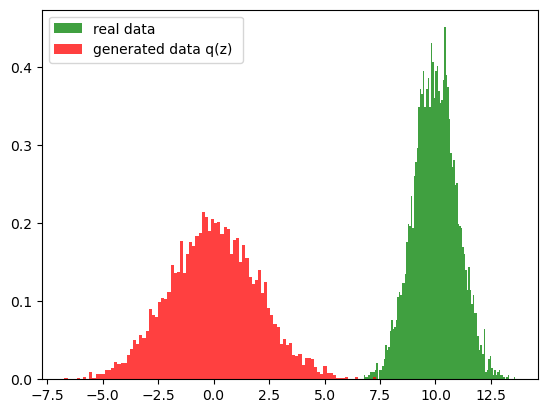

In [72]:
plot_distribution(X, Z, discriminator=None, density=True)

Let's create our first generative model by adding 10 to every sample of $\mathbf{z}$. We will call the result $\hat{\mathbf{x}}$  as it's an approximation of $\mathbf{x}$. It is not too difficult to show that $\hat{\mathbf{x}} \sim \mathcal{N}(\mathbf{x}|10,1)$.


In [73]:
Xhat = Z + 10

We see that the mean and standard deviation are almost identical


In [74]:
print("mean:", np.mean(Xhat))
print("standard deviation:", np.std(Xhat))

mean: 10.006584
standard deviation: 1.9882332


Similarly for the histograms


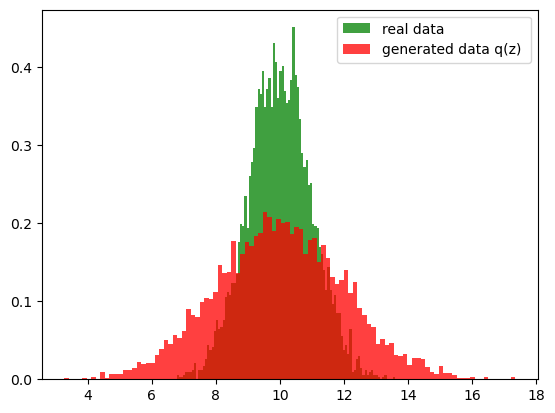

In [75]:
plot_distribution(X, Xhat, discriminator=None, density=True)

In the case above, since we just add 10 to the latent variable $z$, we transform $z$ using a deterministic function. We can call this an implicit generative model.


<a id="The-Generator"></a>
## **The Generator**


A Generative Adversarial Network (GAN) consists of two competing networks: the **Generator** and the **Discriminator**. Let's begin by exploring the Generator.

The Generator's objective is to produce synthetic data that is indistinguishable from real training data. It achieves this by taking a simple input—typically a random noise vector $\mathbf{z}$—and transforming it into a sample $\hat{\mathbf{x}}$.

Mathematically, the Generator is a neural network denoted by $G$, where the mapping is:
$$\hat{\mathbf{x}} = G(\mathbf{z})$$

This approach is grounded in the **Universal Approximation Theorem**, which posits that a neural network can approximate almost any continuous function (see [Universal Approximation Theorem](https://en.wikipedia.org/wiki/Universal_approximation_theorem?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera35714171-2022-01-01)). In the context of GANs, this means that if a mapping exists between a simple distribution (such as Gaussian noise) and the complex distribution of the real data, a neural network can be trained to find and replicate that mapping.

To understand the components:
- $\mathbf{z}$: The **input** (latent variable), usually a vector of random numbers acting as a "seed."
- $G$: The **Generator network**, which processes the noise.
- $\hat{\mathbf{x}}$: The **output** (synthetic sample). The "hat" symbol denotes an approximation of the real data $\mathbf{x}$.

In this lab, we will implement a simplified linear generator defined as:
$$G(\mathbf{z}) = \mathbf{W}^{T}\mathbf{z} + \mathbf{b}$$
- $\mathbf{W}$ (**Weights**): Parameters that scale and rotate the input noise.
- $\mathbf{b}$ (**Bias**): A parameter that shifts the result to the correct position.

The following function implements this Generator using Keras's `Sequential` model.


In [76]:
def make_generator_model():
    generator = tf.keras.Sequential()
    generator.add(layers.Dense(1))
    return generator

We can use the Generator to convert $\mathbf{z}$ and make a prediction $\hat{\mathbf{x}}$, and display the histogram of the distributions of $\hat{\mathbf{x}}$ and $\mathbf{x}$. As the model is not trained, the trained distributions are quite different:


The logic is:

- Input: Random Noise ($\mathbf{z}$) →→ Generator →→ Output: Fake Data ($\hat{\mathbf{x}}$).
- Comparison: Does $\hat{\mathbf{x}}$ (the fake) look like ${\mathbf{x}}$ (the real)?

It is checking if the result of the Generator $\hat{\mathbf{x}}$ (which started from noise $\mathbf{z}$) looks like the real data $\hat{\mathbf{x}}$.

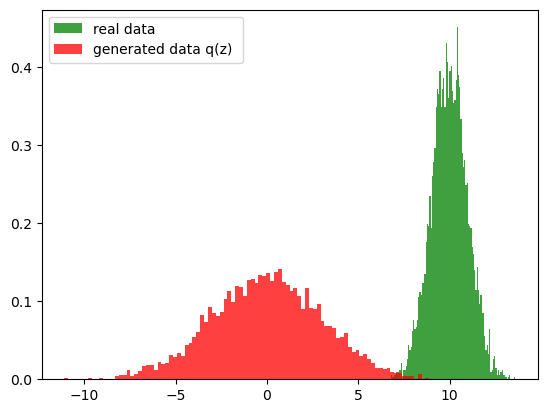

In [77]:
generator = make_generator_model()

Xhat = generator(Z, training=False)
plot_distribution(real_data=X, generated_data=Xhat)

We will discuss `training=False` in more detail later. For now, it means that Keras should run the model in inference mode. In other words, the model makes predictions without updating its weights.

When you call the generator like a function, Keras passes the input `Z` through the model:

```python
Xhat = generator(Z, training=False)
```

In this lab, the generator has one `Dense` layer. For each input value, that layer applies a simple linear calculation:

$$\text{output} = (\text{weight} \times \text{input}) + \text{bias}$$

- **Weight**: A learned value that scales the input. For example, a weight of `0.5` makes the input smaller, while a weight of `-1.2` changes its sign and scale.
- **Bias**: A learned value that shifts the output up or down. For example, a bias of `0.1` adds `0.1` to the result.

At this point, the generator has not been trained yet, so its weight and bias are still close to their initial random values.

<a id="The-Discriminator"></a>
## **The Discriminator**


The discriminator $D(\mathbf{x})$ is a neural network that learns to decide whether a sample looks real or generated.

We do not simply calculate the difference between $\mathbf{x}$ and $\hat{\mathbf{x}}$ because, in a GAN, the generator is trying to match the **distribution** of the real data, not copy each real sample one by one. A fixed distance such as $|\mathbf{x} - \hat{\mathbf{x}}|$ only compares paired values. The discriminator instead learns a decision rule from many real and generated samples.

In this simple one-dimensional example, the discriminator can be implemented as logistic regression: one `Dense(1)` layer produces a score, or **logit**, for each input sample. Higher scores mean the sample is more likely to be real. We do not add a separate sigmoid layer because the Keras binary cross-entropy loss can apply it internally when `from_logits=True`.


In [78]:
def make_discriminator_model():
    discriminator = tf.keras.Sequential()
    discriminator.add(layers.Dense(1))
    return discriminator


discriminator = make_discriminator_model()

At this point, both the generator and the discriminator are still randomly initialized. This means neither model has learned anything useful yet.

The plot helps us see their starting behavior:

- The **green** distribution shows the real data $\mathbf{x}$.
- The **red** distribution shows the generated data $\hat{\mathbf{x}}$.
- The **black** curve shows the discriminator's output after applying the sigmoid function. This value can be interpreted as the discriminator's estimated probability that a sample is real.
- The **blue** horizontal line marks the decision threshold at `0.5`.

If the discriminator output is below `0.5`, the sample is classified as generated, or fake. If the output is above `0.5`, the sample is classified as real.

Because the models have not been trained yet, these classifications are not expected to be good. This plot simply shows the initial state before training begins.


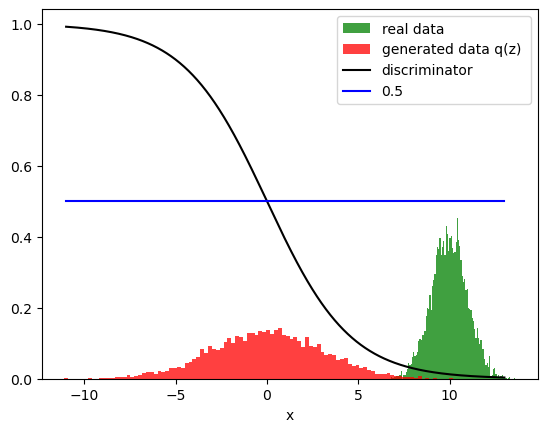

In [79]:
plot_distribution(real_data=X, generated_data=Xhat, discriminator=discriminator)

The discriminator ends with `layers.Dense(1)` and does **not** use a sigmoid activation function. Therefore, its output is a raw score, not a probability.

This raw score can be any real number:

- A larger positive score means the discriminator leans toward "real."
- A larger negative score means the discriminator leans toward "generated."
- A score near zero means the discriminator is uncertain.

Because the output is not a probability, we apply the sigmoid function outside the model when we want to interpret the score:

$$\text{probability real} = \sigma(D(\mathbf{x}))$$

We keep the sigmoid outside the discriminator for two reasons:

1. During training, `BinaryCrossentropy(from_logits=True)` expects the discriminator's raw scores and handles the sigmoid step internally in a numerically stable way.
2. During visualization or counting classifications, probabilities are easier to understand, so we manually apply `tf.math.sigmoid(...)`.

After applying sigmoid, we use `0.5` as the decision threshold:

- Probability greater than `0.5`: classify the sample as real.
- Probability less than `0.5`: classify the sample as generated.

For the real data below, we count how many of the 5000 real samples receive a probability greater than `0.5`.


In [80]:
py_x = tf.math.sigmoid(discriminator(X, training=False))
np.sum(py_x > 0.5)

0

For the generated data, only 1425 out of the 5000 samples are classified as having more than 50% chance of coming from the real distribution.


In [81]:
py_x = discriminator(Xhat)
np.sum(py_x > 0.5)

1755

We can also use the follwoing to find the average value of the sigmoid function for all the samples.


In [82]:
def get_accuracy(X, Xhat):
    total = 0
    py_x = tf.math.sigmoid(discriminator(X, training=False))
    total = np.mean(py_x)
    py_x = tf.math.sigmoid(discriminator(Xhat, training=False))
    total += np.mean(py_x)
    return total / 2

In [83]:
get_accuracy(X, Xhat)

0.2569378912448883

In many cases, we can instead study the difference in the distribution; in this case, the discriminator is called a <a href='https://arxiv.org/pdf/2107.06700.pdf?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera35714171-2022-01-01'>Critic</a>, a real-valued function.


<a id="The-Loss-Function-GANs-Optional"></a>
## **The GAN Loss Function (Optional)**

A GAN has two models with opposite goals:

- The **discriminator** tries to classify samples correctly as real or generated.
- The **generator** tries to create generated samples that the discriminator classifies as real.

This turns the problem into a two-player game. The discriminator improves by learning a better real-vs-generated classifier. The generator improves by learning how to fool that classifier.

In the formulas below, $D(\mathbf{x})$ means the discriminator's estimated probability that sample $\mathbf{x}$ is real. In the code, the discriminator returns a raw score first, and the sigmoid step converts that score into this probability.

<a id="Discriminator"></a>
### **Discriminator**

Start with the usual binary classification objective. Suppose we have training pairs $(\mathbf{x}_n, y_n)$, where:

- $y_n = 1$ means the sample is real.
- $y_n = 0$ means the sample is generated.

For one sample, the log-likelihood is:

$$y_n \log(D(\mathbf{x}_n)) + (1-y_n)\log(1-D(\mathbf{x}_n))$$

This expression rewards the discriminator for assigning high probability to the correct class:

- If $y_n = 1$, only the first term remains: $\log(D(\mathbf{x}_n))$. The discriminator is rewarded when $D(\mathbf{x}_n)$ is close to 1.
- If $y_n = 0$, only the second term remains: $\log(1-D(\mathbf{x}_n))$. The discriminator is rewarded when $D(\mathbf{x}_n)$ is close to 0.

For all samples, the discriminator wants to maximize:

$$V(D)=\sum_{n=1}^{N}\left[y_n\log(D(\mathbf{x}_n))+(1-y_n)\log(1-D(\mathbf{x}_n))\right]$$

In practice, Keras usually minimizes the negative of this expression, which is binary cross-entropy.


For GANs, the discriminator sees two groups of samples:

- Real samples $\mathbf{x}$ from the true data distribution.
- Generated samples $\hat{\mathbf{x}}$ from the generator.

Real samples should be classified as 1, and generated samples should be classified as 0. Therefore, the discriminator objective can be written as:

$$V(D)=\sum_{\mathbf{x}\in \text{real}}\log(D(\mathbf{x})) + \sum_{\hat{\mathbf{x}}\in \text{generated}}\log(1-D(\hat{\mathbf{x}}))$$

The first term rewards the discriminator for giving high probabilities to real samples. The second term rewards it for giving low probabilities to generated samples.


<a id="Generator"></a>
### **Generator**

The generator does not create $\hat{\mathbf{x}}$ directly from nowhere. It starts with random noise $\mathbf{z}$ and transforms it into a generated sample:

$$\hat{\mathbf{x}} = G(\mathbf{z})$$

So we can replace $\hat{\mathbf{x}}$ in the discriminator objective with $G(\mathbf{z})$:

$$V(D,G)=\sum_{\mathbf{x}\in \text{real}}\log(D(\mathbf{x})) + \sum_{\mathbf{z}\in \text{noise}}\log(1-D(G(\mathbf{z})))$$

Now the two models have opposite goals:

- The **discriminator** wants to maximize this value. It wants $D(\mathbf{x})$ to be close to 1 for real samples and $D(G(\mathbf{z}))$ to be close to 0 for generated samples.
- The **generator** wants to minimize this value. It wants $D(G(\mathbf{z}))$ to be close to 1, so the generated samples look real to the discriminator.

Using distribution notation, the same idea is often written with **expectations**. An expectation means an average over many samples.

The notation $\mathbb{E}_{\mathbf{x}\sim p_{data}}$ means:

- sample real data points $\mathbf{x}$ from the real data distribution $p_{data}$,
- compute the expression inside the brackets for each sample,
- then take the average.

The notation $\mathbb{E}_{\mathbf{z}\sim p_z}$ means:

- sample random noise values $\mathbf{z}$ from the noise distribution $p_z$,
- use the generator to turn each $\mathbf{z}$ into $G(\mathbf{z})$,
- compute the expression inside the brackets,
- then take the average.

With that notation, the GAN objective is:

$$V(D,G)=\mathbb{E}_{\mathbf{x}\sim p_{data}}[\log D(\mathbf{x})] + \mathbb{E}_{\mathbf{z}\sim p_{z}}[\log(1-D(G(\mathbf{z})))]$$

The first expectation is the average score for real samples. The second expectation is the average score for generated samples.

This leads to the classic GAN minimax objective:

$$\min_G \max_D V(D,G)$$

Read this as: the discriminator tries to maximize the objective, while the generator tries to minimize it. During training, they improve by competing with each other.


<a id="Training-GANs"></a>
## **Training GANs**

<a id="Training-Generator"></a>
### **Training Generator**

GANs can be difficult to train because the generator and discriminator are trained with opposite goals. We will start with the generator.

The generator takes random noise $\mathbf{z}$ and produces a generated sample:

$$\hat{\mathbf{x}} = G(\mathbf{z})$$

Then the discriminator evaluates that generated sample:

$$D(G(\mathbf{z}))$$

The generator wants the discriminator to believe that its generated samples are real. In other words, when we train the generator, we want $D(G(\mathbf{z}))$ to be close to 1.

From the original GAN objective, the generator could minimize:

$$\log(1-D(G(\mathbf{z})))$$

However, this expression can produce very small gradients early in training. At the beginning, the generator is poor, so the discriminator may confidently classify generated samples as fake. When that happens, the generator learns slowly.

A common practical alternative is to train the generator by maximizing:

$$\log(D(G(\mathbf{z})))$$

This has the same goal: make the discriminator assign a high probability to generated samples. In Keras, optimizers minimize losses, so we minimize the negative version:

$$L_G = -\frac{1}{m}\sum_{k=1}^{m}\log(D(G(\mathbf{z}_k)))$$

Here:

- $m$ is the batch size.
- $\mathbf{z}_k$ is the $k$th random noise sample in the batch.
- $G(\mathbf{z}_k)$ is the generated sample.
- $D(G(\mathbf{z}_k))$ is the discriminator's estimated probability that the generated sample is real.

In the code, this is implemented with binary cross-entropy by pretending the generated samples have label `1`. That means the generator is rewarded when the discriminator classifies generated samples as real.

During this generator update, the generated samples pass through the discriminator, but we only update the generator's weights. The discriminator is used to provide feedback; its weights are not updated in this step.


In [84]:
# This method returns a helper function to compute crossentropy loss
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)


def generator_loss(Xhat):
    return cross_entropy(tf.ones_like(Xhat), Xhat)

<a id="Training-Discriminator"></a>
### **Training Discriminator**

When we train the discriminator, we give it two types of samples:

- Real samples $\mathbf{x}$ from the training data. These should have label `1`.
- Generated samples $G(\mathbf{z})$ from the generator. These should have label `0`.

The discriminator's job is to assign high probabilities to real samples and low probabilities to generated samples.

For real samples, the discriminator loss is:

$$L_{real} = -\frac{1}{m}\sum_{i=1}^{m}\log(D(\mathbf{x}_i))$$

This loss is small when $D(\mathbf{x}_i)$ is close to 1, meaning the discriminator correctly identifies real samples as real.

For generated samples, the discriminator loss is:

$$L_{fake} = -\frac{1}{m}\sum_{i=1}^{m}\log(1-D(G(\mathbf{z}_i)))$$

This loss is small when $D(G(\mathbf{z}_i))$ is close to 0, meaning the discriminator correctly identifies generated samples as fake.

The total discriminator loss combines both parts:

$$L_D = \frac{1}{2}(L_{real} + L_{fake})$$

Here, $m$ is the batch size. The factor $\frac{1}{2}$ averages the real and fake losses.

During this discriminator update, the generator is used only to create generated samples. We update the discriminator's weights, but we do not update the generator's weights in this step.


The first term is the real loss and the second is the fake loss in Keras.


In [85]:
def discriminator_loss(X, Xhat):
    real_loss = cross_entropy(tf.ones_like(X), X)
    fake_loss = cross_entropy(tf.zeros_like(Xhat), Xhat)
    total_loss = 0.5 * (real_loss + fake_loss)
    return total_loss

We create the optimizer for the discriminator and generator:


In [86]:
generator_optimizer = tf.keras.optimizers.Adam(5e-1, beta_1=0.5, beta_2=0.8)

discriminator_optimizer = tf.keras.optimizers.Adam(5e-1, beta_1=0.5, beta_2=0.8)

We now train the GAN. Because this toy dataset is small, each training step uses one large batch of samples.

In each iteration, the code creates two batches:

1. A batch of real samples:

$$\{\mathbf{x}_1, \mathbf{x}_2, \ldots, \mathbf{x}_M\}$$

These samples come from the real data distribution $p(\mathbf{x})$. In this lab, we simulate them with a normal distribution centered near 10. In a real project, this batch would come from the training dataset.

2. A batch of random noise samples:

$$\{\mathbf{z}_1, \mathbf{z}_2, \ldots, \mathbf{z}_M\}$$

These samples come from the noise distribution $p(\mathbf{z})$. The generator transforms each noise sample into a generated sample:

$$\hat{\mathbf{x}}_i = G(\mathbf{z}_i)$$

So the generated batch is:

$$\{\hat{\mathbf{x}}_1, \hat{\mathbf{x}}_2, \ldots, \hat{\mathbf{x}}_M\}$$

Next, the discriminator evaluates both batches:

- `real_output = discriminator(x)` gives scores for the real samples.
- `fake_output = discriminator(xhat)` gives scores for the generated samples.

Then we compute two losses:

- `disc_loss`: trains the discriminator to classify real samples as real and generated samples as fake.
- `gen_loss`: trains the generator to make generated samples that the discriminator classifies as real.

Finally, TensorFlow uses gradients to update the model weights. The generator is updated using `gen_loss`, and the discriminator is updated using `disc_loss`.


GAN convergence can be tricky, even for simple examples. In this toy problem, we use a simple idea to monitor progress.

If the generator becomes very good, the generated data should look like the real data. At that point, the discriminator should no longer be able to reliably tell them apart. Its best guess would be close to random.

For a balanced batch with equal numbers of real and generated samples, random guessing means the discriminator output is close to `0.5`:

$$D(\mathbf{x}_i) \approx 0.5 \quad \text{and} \quad D(\hat{\mathbf{x}}_i) \approx 0.5$$

So, during training, we display iterations where the discriminator's average classification behavior moves closer to `0.5`. This is a simple progress check for this lab, not a complete rule for evaluating all GANs.


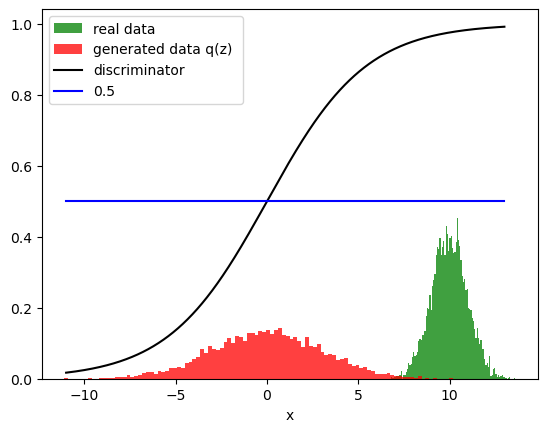

epoch 0


  0%|          | 0/20 [00:00<?, ?it/s]

0.2809211313724518


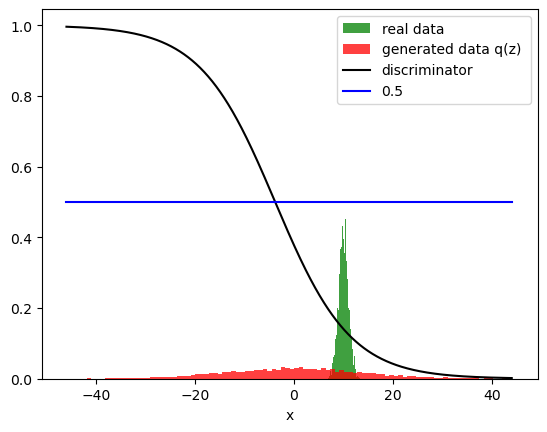

  5%|▌         | 1/20 [00:00<00:06,  3.03it/s]

epoch 0
0.6354902982711792


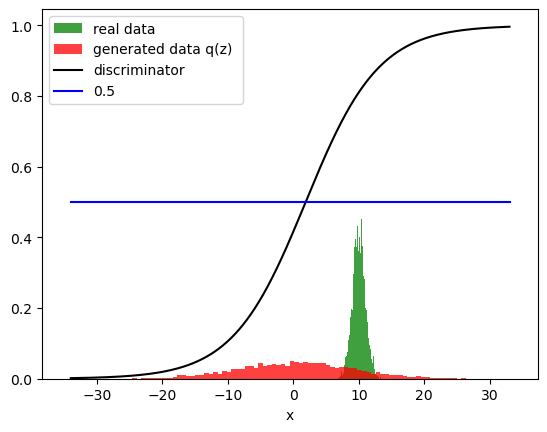

 10%|█         | 2/20 [00:00<00:03,  4.88it/s]

epoch 1
0.625053346157074


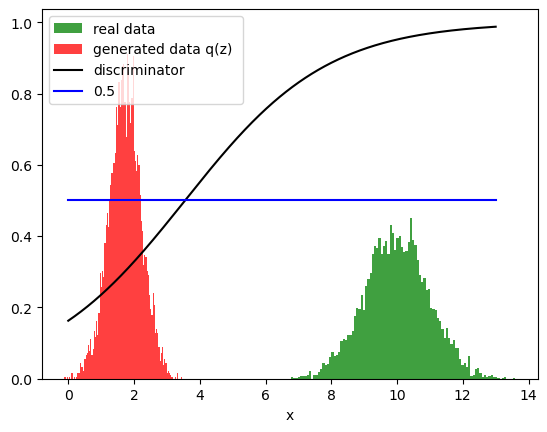

 30%|███       | 6/20 [00:00<00:01, 12.92it/s]

epoch 5
0.5647350549697876


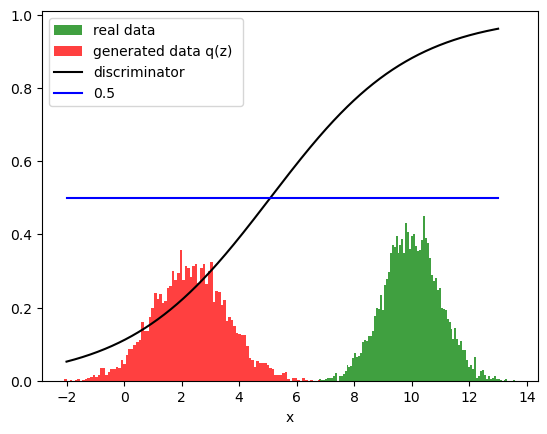

epoch 6
0.5283941626548767


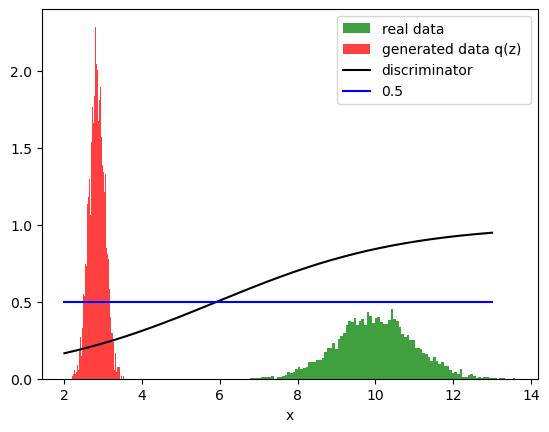

 40%|████      | 8/20 [00:00<00:01, 10.88it/s]

epoch 7
0.5220807790756226


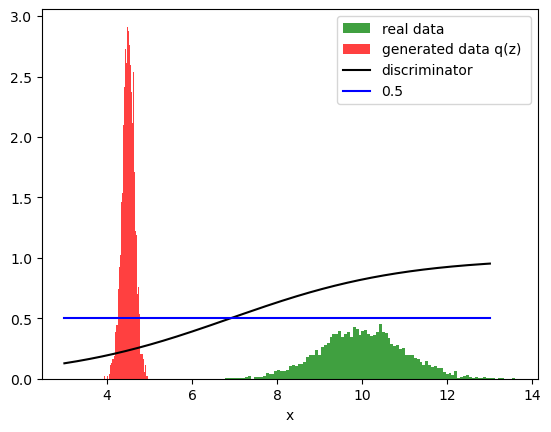

 55%|█████▌    | 11/20 [00:00<00:00, 14.00it/s]

epoch 10


100%|██████████| 20/20 [00:01<00:00, 18.94it/s]


In [87]:
# paramters for trainng
epochs = 20
BATCH_SIZE = 5000
noise_dim = 1
epsilon = 100


# discrimator and gernerator
tf.random.set_seed(0)
discriminator = make_discriminator_model()
generator = make_generator_model()

tf.config.run_functions_eagerly(True)


gen_loss_epoch = []
disc_loss_epoch = []
plot_distribution(real_data=X, generated_data=Xhat, discriminator=discriminator)
print("epoch", 0)

for epoch in tqdm(range(epochs)):
    # data for the true distribution of your real data samples training ste
    x = tf.random.normal((BATCH_SIZE, 1), mean=10, stddev=1.0)
    # random samples it was found if you increase the  stander deviation, you get better results
    z = tf.random.normal([BATCH_SIZE, noise_dim], mean=0, stddev=10)
    # needed to compute the gradients for a list of variables.
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        # generated sample
        xhat = generator(z, training=True)
        # the output of the discriminator for real data
        real_output = discriminator(x, training=True)
        # the output of the discriminator  data
        fake_output = discriminator(xhat, training=True)
        # loss for each
        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)
    # Compute the gradients for gen_loss and generator
    gradients_of_generator = gen_tape.gradient(
        gen_loss, generator.trainable_variables
    )
    # Compute the gradients for gen_loss and discriminator
    gradients_of_discriminator = disc_tape.gradient(
        disc_loss, discriminator.trainable_variables
    )
    # Ask the optimizer to apply the processed gradients
    generator_optimizer.apply_gradients(
        zip(gradients_of_generator, generator.trainable_variables)
    )
    discriminator_optimizer.apply_gradients(
        zip(gradients_of_discriminator, discriminator.trainable_variables)
    )

    # Save and display the generator and discriminator if the performance increases
    if abs(0.5 - get_accuracy(x, xhat)) < epsilon:
        epsilon = abs(0.5 - get_accuracy(x, xhat))
        generator.save("generator.keras")
        discriminator.save("discriminator.keras")
        print(get_accuracy(x, xhat))
        plot_distribution(
            real_data=X, generated_data=xhat, discriminator=discriminator
        )
        print("epoch", epoch)

For more on training GANs check out the following <a href="https://jonathan-hui.medium.com/gan-why-it-is-so-hard-to-train-generative-advisory-networks-819a86b3750b?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera35714171-2022-01-01">blog</a>. We can display the best performing model


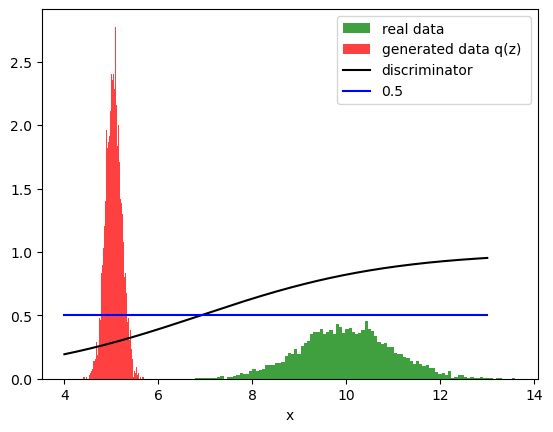

In [88]:
generator = make_generator_model()
generator = models.load_model("generator.keras")
xhat = generator(z)
discriminator = models.load_model("discriminator.keras")
plot_distribution(real_data=X, generated_data=xhat, discriminator=discriminator)

We usually use this version of TensorFlow for the rest of the course, so don't forget to downgrade


In [89]:
# %%capture
#!pip install --upgrade tensorflow==1.14.0

<a id="Modified-Version"></a>
## **Modified Version**

In [ ]:
def plot_data(real_data, fake_data):
    plt.hist(real_data.numpy(), bins=100, alpha=0.6, density=True, label="real")
    plt.hist(
        fake_data.numpy(), bins=100, alpha=0.6, density=True, label="generated"
    )
    plt.legend()
    plt.show()

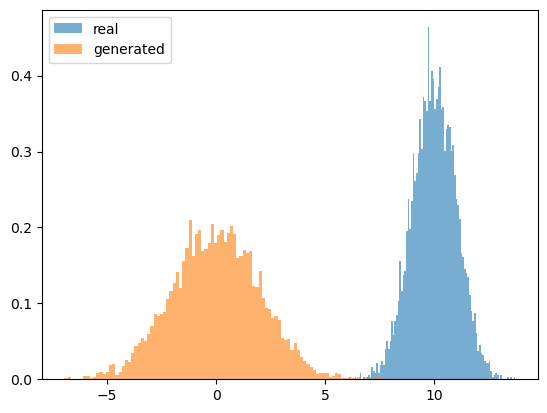

In [91]:
# Real data: samples centered around 10
real_data = tf.random.normal((5000, 1), mean=10.0, stddev=1.0)

# Noise: input to the generator
noise = tf.random.normal((5000, 1), mean=0.0, stddev=2.0)

plot_data(real_data, noise)

In [92]:
def make_generator():
    model = tf.keras.Sequential()
    model.add(layers.Dense(1))
    return model


def make_discriminator():
    model = tf.keras.Sequential()
    model.add(layers.Dense(1))
    return model


generator = make_generator()
discriminator = make_discriminator()

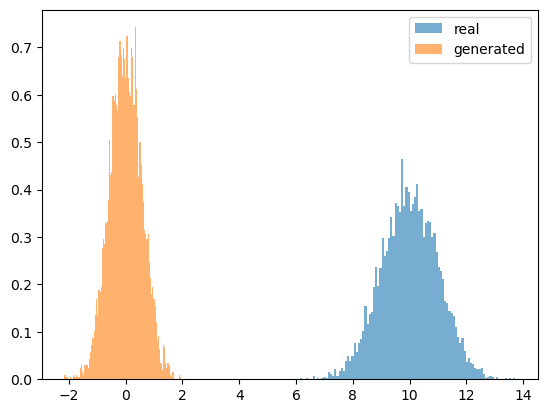

In [93]:
# Before training
fake_data = generator(noise)
plot_data(real_data, fake_data)

In [ ]:
loss_fn = tf.keras.losses.BinaryCrossentropy(from_logits=True)

gen_optimizer = tf.keras.optimizers.Adam(
    learning_rate=5e-1, beta_1=0.5, beta_2=0.8
)
disc_optimizer = tf.keras.optimizers.Adam(
    learning_rate=5e-1, beta_1=0.5, beta_2=0.8
)

In [ ]:
def train_step(batch_size=5000):
    # 1. Make real data
    real_data = tf.random.normal((batch_size, 1), mean=10.0, stddev=1.0)

    # 2. Make random noise
    noise = tf.random.normal((batch_size, 1), mean=0.0, stddev=10.0)

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        # 3. Generator creates fake data
        fake_data = generator(noise, training=True)

        # 4. Discriminator scores real and fake data
        real_scores = discriminator(real_data, training=True)
        fake_scores = discriminator(fake_data, training=True)

        # 5. Discriminator loss
        # Real data should be label 1.
        # Fake data should be label 0.
        real_loss = loss_fn(tf.ones_like(real_scores), real_scores)
        fake_loss = loss_fn(tf.zeros_like(fake_scores), fake_scores)
        disc_loss = 0.5 * (real_loss + fake_loss)

        # 6. Generator loss
        # Generator wants fake data to be classified as real, label 1.
        gen_loss = loss_fn(tf.ones_like(fake_scores), fake_scores)

    # 7. Update generator
    gen_grads = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gen_optimizer.apply_gradients(zip(gen_grads, generator.trainable_variables))

    # 8. Update discriminator
    disc_grads = disc_tape.gradient(
        disc_loss, discriminator.trainable_variables
    )
    disc_optimizer.apply_gradients(
        zip(disc_grads, discriminator.trainable_variables)
    )

    return gen_loss, disc_loss

  0%|          | 0/100 [00:00<?, ?it/s]

epoch: 0 generator loss: 2.002338409423828 discriminator loss: 1.010633945465088


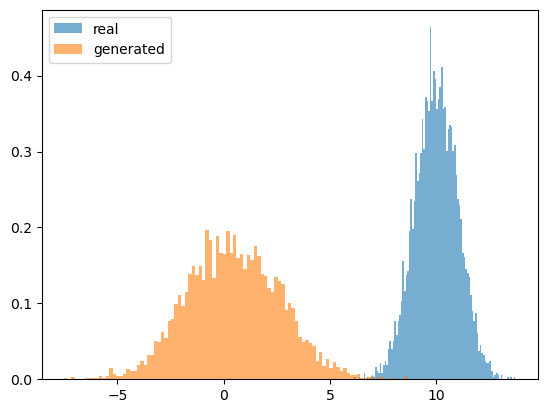

  1%|          | 1/100 [00:00<00:11,  8.32it/s]

epoch: 10 generator loss: 1.5651962757110596 discriminator loss: 0.21301153302192688


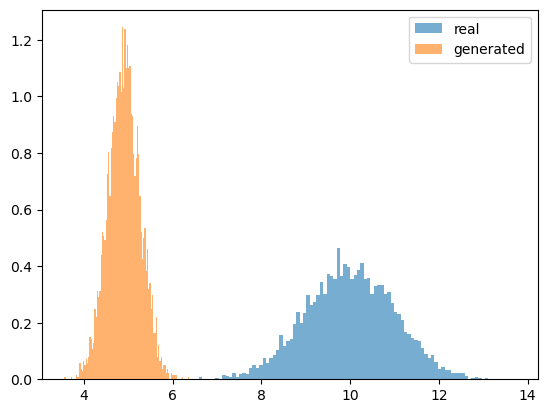

 11%|█         | 11/100 [00:00<00:02, 40.58it/s]

epoch: 20 generator loss: 0.7762842774391174 discriminator loss: 0.6026446223258972


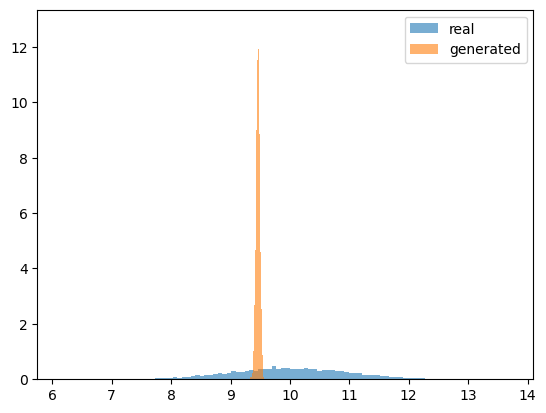

 21%|██        | 21/100 [00:00<00:01, 48.32it/s]

epoch: 30 generator loss: 0.272661030292511 discriminator loss: 1.1599844694137573


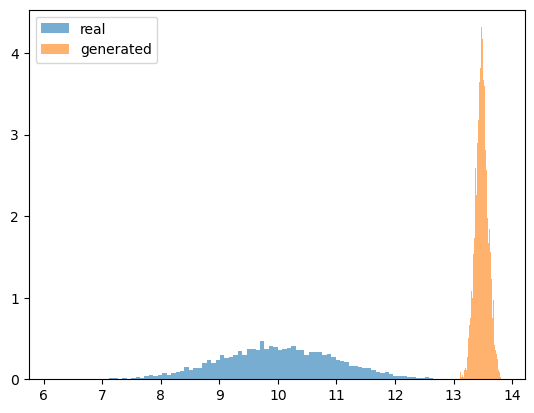

 31%|███       | 31/100 [00:00<00:01, 51.42it/s]

epoch: 40 generator loss: 3.2787833213806152 discriminator loss: 1.6265552043914795


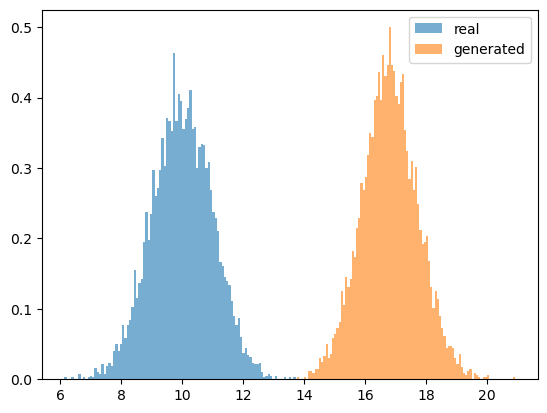

 41%|████      | 41/100 [00:00<00:01, 53.06it/s]

epoch: 50 generator loss: 2.222404718399048 discriminator loss: 0.8490318655967712


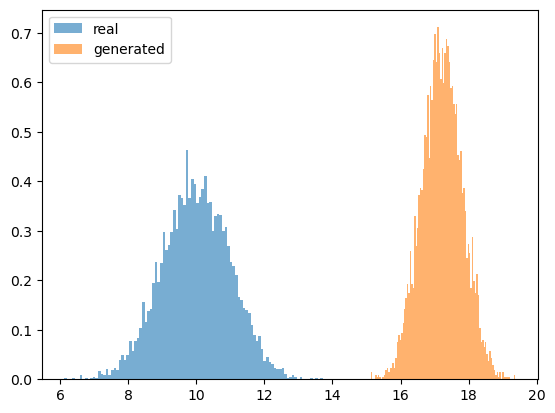

 51%|█████     | 51/100 [00:01<00:00, 53.91it/s]

epoch: 60 generator loss: 1.9428491592407227 discriminator loss: 0.7005521059036255


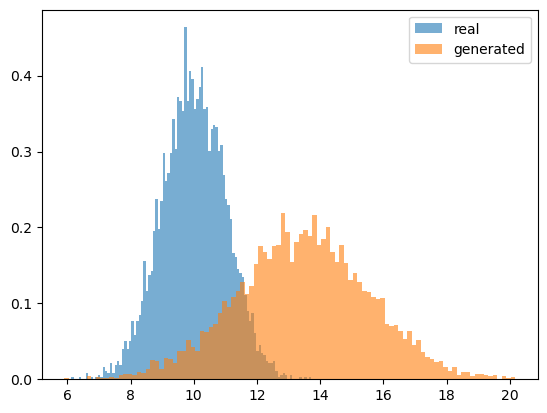

 61%|██████    | 61/100 [00:01<00:00, 40.08it/s]

epoch: 70 generator loss: 1.1521663665771484 discriminator loss: 0.854973554611206


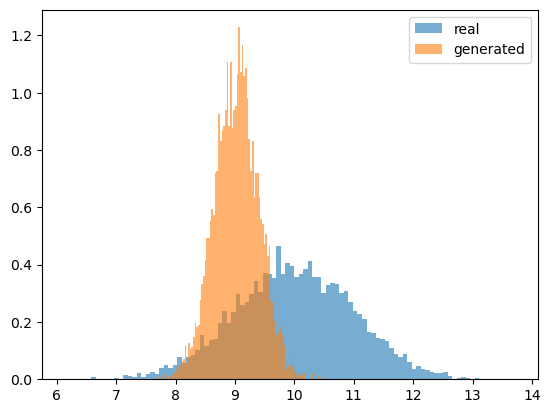

 71%|███████   | 71/100 [00:01<00:00, 42.83it/s]

epoch: 80 generator loss: 0.8203285932540894 discriminator loss: 0.8214130401611328


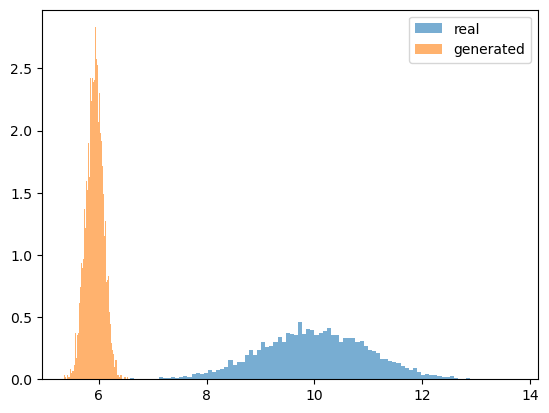

 81%|████████  | 81/100 [00:01<00:00, 46.49it/s]

epoch: 90 generator loss: 0.039135705679655075 discriminator loss: 1.656813621520996


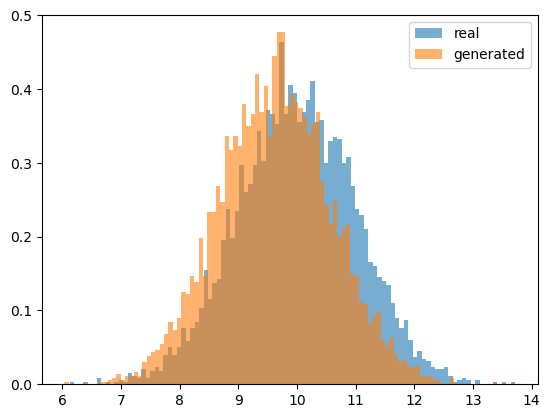

100%|██████████| 100/100 [00:02<00:00, 49.36it/s]


In [96]:
for epoch in tqdm(range(100)):
    gen_loss, disc_loss = train_step()

    if epoch % 10 == 0:
        noise = tf.random.normal((5000, 1), mean=0.0, stddev=10.0)
        fake_data = generator(noise, training=False)

        print(
            "epoch:",
            epoch,
            "generator loss:",
            float(gen_loss),
            "discriminator loss:",
            float(disc_loss),
        )

        plot_data(real_data, fake_data)

## **Author**

<a href="https://www.linkedin.com/in/joseph-s-50398b136/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML0101ENSkillsNetwork20718538-2021-01-01" target="_blank">Joseph Santarcangelo</a>

Su Wu

## **Change Log**

Change Log

| Date (YYYY-MM-DD) | Version | Changed By         | Change Description |
| ----------------- | ------- | ------------------ | ------------------ |
| 2022-06-31        | 0.1     | Joseph Santarcange | Created lab        |
| 2022-09-09        | 0.1     | Steve Hord         | QA pass edits      |
| 2026-05-29     | 0.2     | Su Wu| Documentation and script edits   |

## <h3 align="center"> © IBM Corporation 2022. All rights reserved. <h3/>
